# R 完整实证管线 · Lalonde NSW 数据 | Full Empirical Pipeline in R on the Lalonde NSW Data

**目标**：以经典的 **Lalonde NSW 数据集** 为底，端到端地跑通一篇*应用经济学论文*的完整流程，全程只使用 [`00.3-Full-empirical-analysis-skill_R`](../skills/00.3-Full-empirical-analysis-skill_R/SKILL.md) 推荐的 **现代 tidyverse + 计量经济学 R 技术栈** —— `dplyr`、`fixest`、`MatchIt`、`WeightIt`、`cobalt`、`gtsummary`、`modelsummary`、`marginaleffects`、`DoubleML`、`grf`、`lmtest`、`sandwich`。数据集与姊妹 Python notebook [`statspai_lalonde_full_pipeline.ipynb`](statspai_lalonde_full_pipeline.ipynb) 完全一致：`MatchIt::lalonde` 的 CSV 镜像。

**Goal**: drive a complete *applied-econ paper* end-to-end on the **classic Lalonde NSW dataset**, using only the **modern tidyverse + econometrics R stack** prescribed by [`00.3-Full-empirical-analysis-skill_R`](../skills/00.3-Full-empirical-analysis-skill_R/SKILL.md) — `dplyr`, `fixest`, `MatchIt`, `WeightIt`, `cobalt`, `gtsummary`, `modelsummary`, `marginaleffects`, `DoubleML`, `grf`, `lmtest`, `sandwich`. The dataset is identical to the one in the sister Python notebook [`statspai_lalonde_full_pipeline.ipynb`](statspai_lalonde_full_pipeline.ipynb): the `MatchIt::lalonde` CSV mirror.

**8 个步骤（来自 R skill） | The 8 steps (from the R skill)**:

| 步骤 / Step | 内容 / What | R 主力包 / R workhorse |
|------|------|-------------|
| 1 | 数据导入与清洗 / Data import & cleaning | `readr::read_csv` + `janitor` + `naniar` + `skimr` |
| 2 | 变量构造 / Variable construction | `dplyr::mutate` + `DescTools::Winsorize` |
| 3 | 描述统计与 Table 1 / Descriptives & Table 1 | `gtsummary::tbl_summary` + `modelsummary::datasummary_balance` |
| 4 | 诊断检验 / Diagnostic tests | `lmtest`/`sandwich`/`car` |
| 5 | 基准估计 / Baseline modeling | `fixest::feols` + `MatchIt` + `WeightIt` + `DoubleML` |
| 6 | 稳健性 / Robustness battery | `modelsummary` (M1–M6) + alternative SE / subsample / specification curve |
| 7 | 进一步分析 / Further analysis | `marginaleffects` + `grf::causal_forest` |
| 8 | 出版级图表 / Publication tables & figures | `modelsummary` + `ggplot2` + `cowplot` |

本 notebook 完全可复现：所有单元格均基于公开 CSV 运行，不依赖任何本地数据路径。

This notebook is fully reproducible: every cell runs against the public CSV — no local data path required.

## Step 0: 环境与数据 | Environment and data

**中文说明**：开篇先一次性加载所有要用到的工作包，然后从 Rdatasets 的 `MatchIt` 镜像下载 Lalonde NSW 的 CSV。这里特意使用与 Python notebook **完全相同的 URL**，从而保证两条管线跑的是字节级一致的原始数据，结果可逐项对照。

**English**: We attach the workhorse libraries upfront and download the Lalonde NSW CSV from the Rdatasets `MatchIt` mirror — the **same URL** the Python notebook uses, so both pipelines are running on byte-identical raw data.

In [21]:
# ============================================================
# Step 0: 环境准备
# ============================================================
suppressPackageStartupMessages({
  library(tidyverse)        # tidyverse 全家桶 (dplyr/ggplot2/tidyr/readr/purrr/tibble)
  library(janitor)          # clean_names()——列名统一 snake_case
  library(naniar)           # miss_var_summary()——缺失审计
  library(skimr)            # skim()——一行式概览
  library(DescTools)        # Winsorize()——极值缩尾
  library(gtsummary)        # tbl_summary()——分组 Table 1
  library(modelsummary)     # modelsummary()/datasummary_*——多模型对比表 + 出版级输出
  library(lmtest)           # bptest()/coeftest()/resettest()——异方差/SE 重算/RESET
  library(sandwich)         # vcovHC()——HC0/HC1/HC3 稳健协方差
  library(car)              # vif()——多重共线性
  library(fixest)           # feols()——高性能 OLS / 固定效应回归
  library(MatchIt)          # matchit()——倾向得分匹配
  library(WeightIt)         # weightit()——倾向得分加权 (IPW)
  library(cobalt)           # bal.tab()/love.plot()——加权/匹配后均衡诊断
  library(marginaleffects)  # avg_slopes()/plot_slopes()——边际效应/异质性
  library(DoubleML)         # DoubleMLData/DoubleMLPLR——双重机器学习
  library(mlr3); library(mlr3learners); library(ranger)  # DoubleML 的 nuisance 学习器栈
  library(cowplot)          # plot_grid()——多面板拼图
})

# 全局随机种子：所有抽样 / 子采样估计器都吃这个种子
SEED <- 7
set.seed(SEED)

# 全局 ggplot 主题
theme_set(theme_classic(base_size = 11) +
          theme(legend.position = "bottom",
                plot.title = element_text(face = "bold")))

# 与 Python notebook 完全一致的数据源
DATA_URL <- "https://vincentarelbundock.github.io/Rdatasets/csv/MatchIt/lalonde.csv"

# 打印环境信息，方便复现 (print env info for reproducibility)
cat("R 版本 / R version:           ", R.version$version.string, "\n")
cat("fixest 版本 / fixest version: ", as.character(packageVersion("fixest")), "\n")
cat("MatchIt 版本 / MatchIt version:", as.character(packageVersion("MatchIt")), "\n")
cat("数据 URL / Data URL:          ", DATA_URL, "\n")


R 版本 / R version:            R version 4.5.2 (2025-10-31) 
fixest 版本 / fixest version:  0.14.0 
MatchIt 版本 / MatchIt version: 4.7.2 
数据 URL / Data URL:           https://vincentarelbundock.github.io/Rdatasets/csv/MatchIt/lalonde.csv 


## Step 1: 数据导入与清洗 | Data import and cleaning

**中文说明**：Skill 第 1 节规定的标准动作是 `read_*` → `janitor::clean_names`（列名统一为 snake_case）→ `skim` 一行式概览 → `naniar::miss_var_summary` 缺失审计 → 用 `stopifnot()` 显式断言面板键。Lalonde 是*横截面*数据，所以面板键断言退化为对类似 `id` 列的行级唯一性检查。

**English**: Skill section 1 prescribes: `read_*` → `janitor::clean_names` → `skim` for the one-line summary → `naniar::miss_var_summary` for missingness → explicit `stopifnot()` panel-key assertions. Lalonde is *cross-sectional*, so the panel-key assertion becomes a row-uniqueness check on the `id`-style column.

In [22]:
# ============================================================
# Step 1: 导入 + 清洗
# ============================================================

# 1a. 读 CSV + clean_names —— 列名一律 snake_case
raw <- readr::read_csv(DATA_URL, show_col_types = FALSE)
df  <- raw %>% janitor::clean_names()

cat("原始数据 / Raw shape:", nrow(df), "行 rows ×", ncol(df), "列 cols\n")
print(head(df, 5))

# 1b. dtype 检查
cat("\n--- 列类型 / column types ---\n")
print(sapply(df, class))

# 1c. skimr 一行式概览（连续 + 离散分别给）
cat("\n--- skim() 一行式概览 / summary ---\n")
print(skimr::skim(df))

# 1d. 缺失审计
cat("\n--- 缺失审计 / miss_var_summary ---\n")
print(naniar::miss_var_summary(df))

# 1e. Rdatasets 给的 rownames 列是字符串 ID（"NSW1"...）；行级唯一即可丢
stopifnot(length(unique(df$rownames)) == nrow(df))
df <- df %>% select(-any_of("rownames"))
n_dup <- sum(duplicated(df))
cat("\n丢掉 rownames 后行数 / Rows after rownames drop:", nrow(df),
    " (", n_dup, " 行协变量向量重复 — 小样本下的正常现象，不是数据质量问题 / ",
    "rows share an identical covariate vector — small-N artifact, ",
    "not a data-quality issue)\n", sep = "")

# 1f. 关键变量不能有缺失
key_vars <- c("treat", "re78", "age", "educ", "race", "married", "nodegree",
              "re74", "re75")
df <- df %>% drop_na(all_of(key_vars))
stopifnot(all(df$treat %in% c(0, 1)))
cat("对关键变量 drop_na 后 / After drop_na on keys:", nrow(df), "行 rows\n")
cat("处理组人数 / Treatment counts:\n"); print(table(df$treat,
                                          dnn = list("0 = 对照 control / 1 = 处理 treated")))


原始数据 / Raw shape: 614 行 rows × 10 列 cols
# A tibble: 5 × 10
  rownames treat   age  educ race   married nodegree  re74  re75   re78
  <chr>    <dbl> <dbl> <dbl> <chr>    <dbl>    <dbl> <dbl> <dbl>  <dbl>
1 NSW1         1    37    11 black        1        1     0     0  9930.
2 NSW2         1    22     9 hispan       0        1     0     0  3596.
3 NSW3         1    30    12 black        0        0     0     0 24909.
4 NSW4         1    27    11 black        0        1     0     0  7506.
5 NSW5         1    33     8 black        0        1     0     0   290.

--- 列类型 / column types ---
   rownames       treat         age        educ        race     married 
"character"   "numeric"   "numeric"   "numeric" "character"   "numeric" 
   nodegree        re74        re75        re78 
  "numeric"   "numeric"   "numeric"   "numeric" 

--- skim() 一行式概览 / summary ---
── Data Summary ────────────────────────
                           Values
Name                       df    
Number of rows         

## Step 2: 变量构造 | Variable construction

**中文说明**：变量编码与 Python notebook 完全保持一致，确保两条管线可以一一对照：把 `race` 拆成 `black` / `hispan` 两个 0/1 哑变量；用 IHS 风格的 `pmax(x, 1)` 哨兵把结果取对数；同时保留两版结果变量 —— 原始 `re78`（水平值，单位美元）和 `log_re78`（半弹性）。所有处理前协变量被打包成一个统一的向量 `covariates`，下游的均衡 / 匹配 / IPW / DML 估计器都复用这同一份。

**English**: We follow the same encoding as the Python notebook so the two pipelines are comparable: split `race` into `black`/`hispan` 0/1 indicators, log the outcome with the IHS-friendly `pmax(x, 1)` guard, and stage two outcome variants — raw `re78` (level, in dollars) and `log_re78` (semi-elasticity). All pre-treatment covariates are then bundled into one vector that downstream balance / matching / DML estimators reuse.

In [23]:
# ============================================================
# Step 2: 变量构造
# ============================================================

df <- df %>%
  mutate(
    # 2a. race 拆成两个 0/1 dummy（与 Python notebook 完全一致）
    black  = as.integer(race == "black"),
    hispan = as.integer(race == "hispan"),
    # 2b. 1 = 有 1974 实际收入 = 0 的样本 —— Lalonde 经典经验上的 "no earnings in 74"
    u74 = as.integer(re74 == 0),
    u75 = as.integer(re75 == 0),
    # 2c. 1/99 winsorized 收入版本（稳健性用）
    re78_w = DescTools::Winsorize(re78,
                                  val = quantile(re78, probs = c(0.01, 0.99),
                                                 na.rm = TRUE)),
    # 2d. log 结果（IHS 风格，避免 log(0)）
    log_re78 = log(pmax(re78, 1)),
    # 2e. 多项式 / 标准化
    age_sq   = age^2,
    age_std  = as.numeric(scale(age))
  )

# 2f. 协变量集合 —— 一个对象给所有后续步骤复用
covariates <- c("age", "educ", "black", "hispan", "married", "nodegree",
                "re74", "re75")
analysis_vars <- c("treat", "re78", "log_re78", covariates)

# 2g. 体检：分析变量没有缺失 + treat 严格 0/1
stopifnot(sum(is.na(df[analysis_vars])) == 0)
stopifnot(setequal(unique(df$treat), c(0, 1)))

# 2h. 紧凑展示
cat("最终分析数据集 / Final analysis frame:", nrow(df), "行 rows ×", ncol(df), "列 cols\n")
cat("协变量集合 / Covariate set:\n  ", paste(covariates, collapse = ", "), "\n")
cat("结果变量(水平) / Outcome (level):  re78        (取值范围 / range:",
    range(df$re78), ")\n")
cat("结果变量(对数) / Outcome (log):    log_re78    (取值范围 / range:",
    round(range(df$log_re78), 2), ")\n")
print(head(df %>% select(treat, re78, log_re78, all_of(covariates)), 5))


最终分析数据集 / Final analysis frame: 614 行 rows × 17 列 cols
协变量集合 / Covariate set:
   age, educ, black, hispan, married, nodegree, re74, re75 
结果变量(水平) / Outcome (level):  re78        (取值范围 / range: 0 60307.93 )
结果变量(对数) / Outcome (log):    log_re78    (取值范围 / range: 0 11.01 )
# A tibble: 5 × 11
  treat   re78 log_re78   age  educ black hispan married nodegree  re74  re75
  <dbl>  <dbl>    <dbl> <dbl> <dbl> <int>  <int>   <dbl>    <dbl> <dbl> <dbl>
1     1  9930.     9.20    37    11     1      0       1        1     0     0
2     1  3596.     8.19    22     9     0      1       0        1     0     0
3     1 24909.    10.1     30    12     1      0       0        0     0     0
4     1  7506.     8.92    27    11     1      0       0        1     0     0
5     1   290.     5.67    33     8     1      0       0        1     0     0


## Step 3: 描述统计与协变量均衡 | Descriptive statistics and covariate balance

**中文说明**：Skill 第 3 节明确——现代 Table 1 的标配是 `gtsummary::tbl_summary()`（按组分层，附 SMD 与 p 值）加上 `modelsummary::datasummary_balance()`（出版级均衡表）。我们把两者都渲染出来，再画出*未匹配的原始* `log_re78` 与关键连续协变量在处理状态下的分布 —— 这是经典的*动机性*图：直观显示 NSW 对照组在任何调整之前是多么 *non-randomized*。

**English**: Skill section 3 says the modern Table-1 stack is `gtsummary::tbl_summary()` (group-stratified, with SMDs and p-values) plus `modelsummary::datasummary_balance()` for a publication-style balance table. We render both, then plot the *raw, unmatched* distribution of `log_re78` and key continuous covariates by treatment status — a classic *motivation* figure showing how non-randomized the NSW comparison group looks before any adjustment.

In [24]:
# ============================================================
# Step 3a: gtsummary 分组 Table 1 —— 含 SMD 与 p 值
# ============================================================
tbl1 <- df %>%
  mutate(treat_lab = factor(treat, levels = c(0, 1),
                            labels = c("Control", "Treated"))) %>%
  select(treat_lab, age, educ, black, hispan, married, nodegree,
         re74, re75, re78) %>%
  tbl_summary(
    by = treat_lab,
    statistic = list(all_continuous() ~ "{mean} ({sd})",
                     all_dichotomous() ~ "{n} ({p}%)"),
    digits = list(all_continuous() ~ 2),
    missing = "ifany"
  ) %>%
  add_n() %>%
  add_p() %>%
  add_overall() %>%
  modify_header(label = "**Variable**") %>%
  bold_labels()
print(tbl1)


<div id="jsgbozvhxc" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#jsgbozvhxc table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#jsgbozvhxc thead, #jsgbozvhxc tbody, #jsgbozvhxc tfoot, #jsgbozvhxc tr, #jsgbozvhxc td, #jsgbozvhxc th {
  border-style: none;
}

#jsgbozvhxc p {
  margin: 0;
  padding: 0;
}

#jsgbozvhxc .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 16px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: auto;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #A8A8A8;
  border-right-style: none;
  border-right-width: 2px;
  b

In [25]:
# ============================================================
# Step 3b: modelsummary::datasummary_balance —— 含 SMD
# ============================================================
bal_tbl <- datasummary_balance(
  ~ treat,
  data = df %>% select(treat, age, educ, black, hispan, married, nodegree,
                        re74, re75, re78),
  output = "data.frame"
)
print(bal_tbl)


Warning message:
“Please install the `estimatr` package or set `dinm=FALSE` to suppress this warning.”


           0 / Mean 0 / Std. Dev. 1 / Mean 1 / Std. Dev.
1      age     28.0          10.8     25.8           7.2
2     educ     10.2           2.9     10.3           2.0
3    black      0.2           0.4      0.8           0.4
4   hispan      0.1           0.3      0.1           0.2
5  married      0.5           0.5      0.2           0.4
6 nodegree      0.6           0.5      0.7           0.5
7     re74   5619.2        6788.8   2095.6        4886.6
8     re75   2466.5        3292.0   1532.1        3219.3
9     re78   6984.2        7294.2   6349.1        7867.4


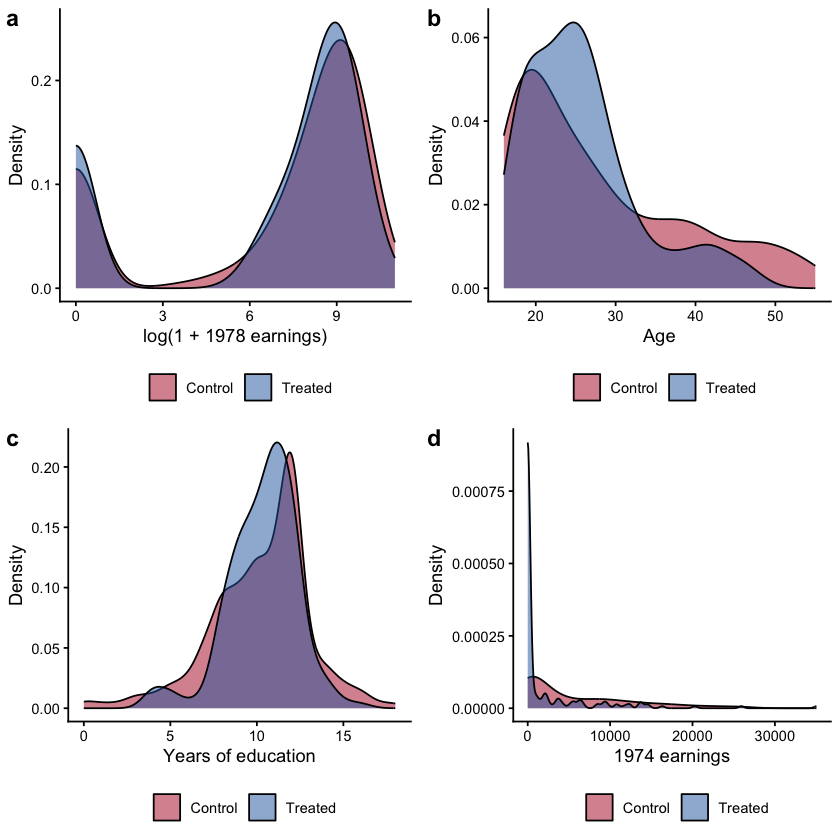

In [26]:
# ============================================================
# Step 3c: 关键变量在 treat=0/1 下的分布图
# ============================================================
plot_dens <- function(varname, xlab) {
  ggplot(df, aes(.data[[varname]], fill = factor(treat))) +
    geom_density(alpha = 0.5) +
    scale_fill_manual(values = c("0" = "#B2182B", "1" = "#2166AC"),
                      labels = c("Control", "Treated"), name = "") +
    labs(x = xlab, y = "Density") +
    theme(legend.position = "bottom")
}
p1 <- plot_dens("log_re78", "log(1 + 1978 earnings)")
p2 <- plot_dens("age",     "Age")
p3 <- plot_dens("educ",    "Years of education")
p4 <- plot_dens("re74",    "1974 earnings")

cowplot::plot_grid(p1, p2, p3, p4, ncol = 2, labels = "auto")


## Step 4: 诊断检验 | Diagnostic tests

**中文说明**：横截面 + selection-on-observables 设计下，Skill §4 中真正用得上的检验只有这四个：

- **异方差** —— `lmtest::bptest()`，决定是否默认走 HC3 稳健标准误。
- **多重共线性** —— `car::vif()`，检查协变量集合是否退化（最容易出问题的是 `re74`/`re75`/`u74`/`u75` 这一族）。
- **函数形式** —— `lmtest::resettest()`，检测被遗漏的非线性。
- **残差正态性** —— `shapiro.test()`，告诉我们当前 `N` 下能否放心依赖 OLS 系数的渐近正态性。

Skill 里提到的*平行趋势* / *自相关* / *单位根*检验在这里都不适用（数据没有时间维度）。

**English**: For a cross-sectional selection-on-observables design, the relevant tests from skill §4 are:

- **Heteroskedasticity** — `lmtest::bptest()` decides whether to default to HC3 robust SEs.
- **Multicollinearity** — `car::vif()` checks that the covariate set is not degenerate (the `re74`/`re75`/`u74`/`u75` family is most at risk).
- **Functional form** — `lmtest::resettest()` flags missing nonlinearity.
- **Residual normality** — `shapiro.test()` informs whether asymptotic normality of OLS coefficients is safe at this `N`.

The *parallel-trends* / *autocorrelation* / *unit-root* tests in the skill don't apply here (no time dimension).

In [27]:
# ============================================================
# Step 4: 诊断检验 (cross-sectional, selection on observables)
# ============================================================
# 用最朴素的 OLS 当“诊断载体”
ols_diag <- lm(log_re78 ~ treat + age + educ + black + hispan + married +
                          nodegree + re74 + re75, data = df)

# 4a. 异方差 —— Breusch–Pagan
cat("--- Breusch-Pagan 异方差检验 (H0: 同方差 / homoskedastic) ---\n")
print(lmtest::bptest(ols_diag))

# 4b. 多重共线性 —— VIF
cat("\n--- VIF 多重共线性 / Variance Inflation Factors ---\n")
print(round(car::vif(ols_diag), 2))
cat("VIF 经验法则 / rule of thumb: 任一值 > 10 即考虑剔除或合并 (drop / combine)\n")

# 4c. 函数形式 —— RESET
cat("\n--- RESET 函数形式检验 / specification test ---\n")
print(lmtest::resettest(ols_diag, power = 2:3, type = "fitted"))

# 4d. 残差正态性 —— Shapiro–Wilk
cat("\n--- 残差正态性 / Shapiro-Wilk on residuals ---\n")
print(shapiro.test(residuals(ols_diag)))

cat("\n决策小结 / Decision summary:\n",
    "  - BP 显著 / rejects -> 默认走 HC3 稳健 SE (sandwich::vcovHC, type = 'HC3')\n",
    "  - VIF 全部 <10 / all <10 -> 协变量集合不共线 (covariate set is not collinear)\n",
    "  - RESET 显著 / rejects -> 引入非线性项 (Step 6/7 加 age^2 + 交互)\n",
    "  - Shapiro 显著 / rejects -> 依赖 N=", nrow(df),
    " 的渐近正态性 / rely on asymptotic normality\n", sep = "")


--- Breusch-Pagan 异方差检验 (H0: 同方差 / homoskedastic) ---

	studentized Breusch-Pagan test

data:  ols_diag
BP = 22.285, df = 9, p-value = 0.008018


--- VIF 多重共线性 / Variance Inflation Factors ---
   treat      age     educ    black   hispan  married nodegree     re74 
    1.63     1.31     2.22     1.80     1.17     1.49     2.13     1.81 
    re75 
    1.51 
VIF 经验法则 / rule of thumb: 任一值 > 10 即考虑剔除或合并 (drop / combine)

--- RESET 函数形式检验 / specification test ---

	RESET test

data:  ols_diag
RESET = 1.0441, df1 = 2, df2 = 602, p-value = 0.3526


--- 残差正态性 / Shapiro-Wilk on residuals ---

	Shapiro-Wilk normality test

data:  residuals(ols_diag)
W = 0.82574, p-value < 2.2e-16


决策小结 / Decision summary:
  - BP 显著 / rejects -> 默认走 HC3 稳健 SE (sandwich::vcovHC, type = 'HC3')
  - VIF 全部 <10 / all <10 -> 协变量集合不共线 (covariate set is not collinear)
  - RESET 显著 / rejects -> 引入非线性项 (Step 6/7 加 age^2 + 交互)
  - Shapiro 显著 / rejects -> 依赖 N=614 的渐近正态性 / rely on asymptotic normality


## Step 5: 估计 | Baseline estimation

**中文说明**：Skill 的识别策略表把**横截面 + selection-on-observables** 这类问题分配给以下五个估计量：

1. **朴素 OLS** —— `feols(log_re78 ~ treat)`，作为基线对照。
2. **OLS + 协变量 + HC3 稳健 SE** —— `feols(... vcov = "hetero")`。
3. **MatchIt（基于倾向得分的 1 对 1 最近邻匹配）→ 在匹配集上做结果回归**。
4. **WeightIt（基于倾向得分的 IPW 加权）→ 加权回归**。
5. **DoubleML PLR（partialling-out / AIPW，nuisance 用随机森林学习器）** —— 现代 ML-causal 估计量。

最后我们把五种估计量堆到同一张对比表里，让各种识别策略一眼可比。

**English**: The skill's identification-strategy table sends a **cross-section + selection-on-observables** problem to four estimators:

1. **Naive OLS** — `feols(log_re78 ~ treat)` baseline.
2. **OLS + covariates with HC3 robust SEs** — `feols(... vcov = "hetero")`.
3. **MatchIt (1-to-1 nearest-neighbor on propensity score) → outcome regression on the matched set**.
4. **WeightIt (IPW by propensity) → weighted regression**.
5. **DoubleML PLR (partialling-out / AIPW with random forests)** — the modern ML-causal estimator.

We then stack all five into one comparison table.

In [28]:
# ============================================================
# Step 5a: Naive OLS + OLS with HC3 robust SEs (using fixest::feols)
# ============================================================
m_ols_naive <- feols(log_re78 ~ treat, data = df, vcov = "hetero")
m_ols_full  <- feols(log_re78 ~ treat + age + educ + black + hispan +
                                married + nodegree + re74 + re75,
                     data = df, vcov = "hetero")
summary(m_ols_naive)
cat("\n----------------------------------------\n")
summary(m_ols_full)


OLS estimation, Dep. Var.: log_re78
Observations: 614
Standard-errors: Heteroskedasticity-robust 
             Estimate Std. Error   t value  Pr(>|t|)    
(Intercept)  6.648058   0.182797 36.368586 < 2.2e-16 ***
treat       -0.141379   0.334046 -0.423232   0.67227    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 3.78501   Adj. R2: -0.00134


----------------------------------------


OLS estimation, Dep. Var.: log_re78
Observations: 614
Standard-errors: Heteroskedasticity-robust 
             Estimate Std. Error   t value   Pr(>|t|)    
(Intercept)  6.216078   1.361809  4.564575 6.0664e-06 ***
treat        0.893627   0.402907  2.217950 2.6929e-02 *  
age         -0.053593   0.018066 -2.966495 3.1312e-03 ** 
educ         0.119519   0.087612  1.364178 1.7302e-01    
black       -1.145641   0.404496 -2.832268 4.7760e-03 ** 
hispan       0.306690   0.472396  0.649223 5.1644e-01    
married      0.095787   0.367639  0.260546 7.9453e-01    
nodegree     0.155771   0.450187  0.346013 7.2945e-01    
re74         0.000077   0.000029  2.653685 8.1714e-03 ** 
re75         0.000132   0.000048  2.754968 6.0467e-03 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 3.62782   Adj. R2: 0.067924

In [29]:
# ============================================================
# Step 5b: MatchIt 最近邻匹配 + 匹配后回归
# ============================================================
match_form <- as.formula(paste("treat ~", paste(covariates, collapse = " + ")))

m_match <- matchit(match_form, data = df,
                   method = "nearest", distance = "glm",
                   link = "logit", ratio = 1, replace = FALSE)
print(summary(m_match, un = FALSE))    # 匹配后均衡 / post-match balance

# 匹配数据
m_data <- match.data(m_match)
cat("\n匹配后样本量 / Matched sample size:", nrow(m_data), "行 rows\n")

# 在匹配集上跑加权 OLS：matched-weights + 按 subclass 聚类
# (weighted OLS on matched data: matched-weights + cluster on subclass)
m_match_reg <- feols(log_re78 ~ treat + age + educ + black + hispan +
                                 married + nodegree + re74 + re75,
                     data = m_data,
                     weights = ~ weights,
                     cluster = ~ subclass)
summary(m_match_reg)



Call:
matchit(formula = match_form, data = df, method = "nearest", 
    distance = "glm", link = "logit", replace = FALSE, ratio = 1)

Summary of Balance for Matched Data:
         Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance        0.5774        0.3629          0.9739     0.7566    0.1324
age            25.8162       25.3027          0.0718     0.4568    0.0847
educ           10.3459       10.6054         -0.1290     0.5721    0.0239
black           0.8432        0.4703          1.0259          .    0.3730
hispan          0.0595        0.2162         -0.6629          .    0.1568
married         0.1892        0.2108         -0.0552          .    0.0216
nodegree        0.7081        0.6378          0.1546          .    0.0703
re74         2095.5737     2342.1076         -0.0505     1.3289    0.0469
re75         1532.0553     1614.7451         -0.0257     1.4956    0.0452
         eCDF Max Std. Pair Dist.
distance   0.4216          0.9740
age        0.2541  

OLS estimation, Dep. Var.: log_re78
Observations: 370
Weights: weights
Standard-errors: Clustered (subclass) 
             Estimate Std. Error   t value  Pr(>|t|)    
(Intercept)  5.616539   1.933541  2.904794 0.0041254 ** 
treat        0.788397   0.412920  1.909322 0.0577765 .  
age         -0.045051   0.025557 -1.762799 0.0795945 .  
educ         0.151647   0.123070  1.232203 0.2194457    
black       -0.960085   0.492929 -1.947714 0.0529708 .  
hispan       0.667788   0.576827  1.157693 0.2484899    
married      0.015478   0.545989  0.028349 0.9774145    
nodegree     0.427017   0.595823  0.716684 0.4744775    
re74        -0.000014   0.000053 -0.262131 0.7935135    
re75         0.000124   0.000074  1.672634 0.0960988 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 3.70593   Adj. R2: 0.029297

In [30]:
# ============================================================
# Step 5c: WeightIt IPW + 加权回归
# ============================================================
m_w <- weightit(match_form, data = df, method = "glm",
                estimand = "ATT")
cat("IPW 后的有效样本量 / Effective sample size after IPW:\n")
print(summary(m_w))

# 用 cobalt 看权重后均衡
print(cobalt::bal.tab(m_w, un = TRUE, m.threshold = 0.1))

# 加 IPW 权重的 OLS，配 HC3 稳健 SE / weighted OLS with IPW + HC3 robust SEs
df_w <- df %>% mutate(ipw = m_w$weights)
m_ipw_reg <- feols(log_re78 ~ treat + age + educ + black + hispan +
                              married + nodegree + re74 + re75,
                   data = df_w, weights = ~ ipw, vcov = "hetero")
summary(m_ipw_reg)


IPW 后的有效样本量 / Effective sample size after IPW:
                  Summary of weights

- Weight ranges:

          Min                                 Max
treated 1.            ||                    1.   
control 0.009 |---------------------------| 3.743

- Units with the 5 most extreme weights by group:
                                    
            5     4    3     2     1
 treated    1     1    1     1     1
          597   573  381   411   303
 control 3.03 3.059 3.24 3.523 3.743

- Weight statistics:

        Coef of Var   MAD Entropy # Zeros
treated       0.    0.      0.          0
control       1.818 1.289   1.098       0

- Effective Sample Sizes:

           Control Treated
Unweighted  429.       185
Weighted     99.82     185
Balance Measures
               Type Diff.Un Diff.Adj        M.Threshold
prop.score Distance  1.7941  -0.0205     Balanced, <0.1
age         Contin. -0.3094   0.1188 Not Balanced, >0.1
educ        Contin.  0.0550  -0.0284     Balanced, <0.1
black       

OLS estimation, Dep. Var.: log_re78
Observations: 614
Weights: ipw
Standard-errors: Heteroskedasticity-robust 
             Estimate Std. Error   t value  Pr(>|t|)    
(Intercept)  5.973114   2.092245  2.854883 0.0044531 ** 
treat        0.550420   0.443898  1.239969 0.2154683    
age         -0.058254   0.027925 -2.086098 0.0373887 *  
educ         0.188219   0.132994  1.415243 0.1575128    
black       -1.171186   0.450251 -2.601183 0.0095179 ** 
hispan       0.382708   0.544648  0.702671 0.4825313    
married      0.275500   0.567606  0.485373 0.6275880    
nodegree     0.339006   0.687201  0.493314 0.6219699    
re74        -0.000040   0.000054 -0.742497 0.4580750    
re75         0.000193   0.000073  2.657157 0.0080887 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 3.67183   Adj. R2: 0.05626

In [31]:
# ============================================================
# Step 5d: DoubleML PLR (Partial Linear Regression with random forest)
# ============================================================
set.seed(SEED)

dml_data <- DoubleMLData$new(
  data    = as.data.frame(df %>% select(log_re78, treat, all_of(covariates))),
  y_col   = "log_re78",
  d_cols  = "treat",
  x_cols  = covariates
)

# nuisance 学习器：用随机森林同时拟合 g(X)=E[Y|X] 与 m(X)=E[D|X]
# (nuisance learners: random forest for both g(X)=E[Y|X] and m(X)=E[D|X])
ml_g <- lrn("regr.ranger",     num.trees = 500, min.node.size = 5)
ml_m <- lrn("classif.ranger",  num.trees = 500, min.node.size = 5)

m_dml <- DoubleMLPLR$new(dml_data, ml_l = ml_g, ml_m = ml_m,
                          n_folds = 5, n_rep = 1)
m_dml$fit()
print(m_dml)


INFO  [01:27:53.022] [mlr3] Applying learner 'regr.ranger' on task 'nuis_l' (iter 1/5)
INFO  [01:27:53.103] [mlr3] Applying learner 'regr.ranger' on task 'nuis_l' (iter 2/5)
INFO  [01:27:53.194] [mlr3] Applying learner 'regr.ranger' on task 'nuis_l' (iter 3/5)
INFO  [01:27:53.281] [mlr3] Applying learner 'regr.ranger' on task 'nuis_l' (iter 4/5)
INFO  [01:27:53.361] [mlr3] Applying learner 'regr.ranger' on task 'nuis_l' (iter 5/5)
INFO  [01:27:53.544] [mlr3] Applying learner 'classif.ranger' on task 'nuis_m' (iter 1/5)
INFO  [01:27:53.630] [mlr3] Applying learner 'classif.ranger' on task 'nuis_m' (iter 2/5)
INFO  [01:27:53.702] [mlr3] Applying learner 'classif.ranger' on task 'nuis_m' (iter 3/5)
INFO  [01:27:53.774] [mlr3] Applying learner 'classif.ranger' on task 'nuis_m' (iter 4/5)
INFO  [01:27:53.845] [mlr3] Applying learner 'classif.ranger' on task 'nuis_m' (iter 5/5)
================= DoubleMLPLR Object ==================


------------------ Data summary      ------------------
O

In [32]:
# ============================================================
# Step 5e: 五种估计量的对比表
# ============================================================
# 把 DML 的点估计 / SE 包成 modelsummary 能识别的 "glance-able" 列表
# (wrap DML estimate / SE into a "glance-able" list for modelsummary)
dml_tidy <- tibble::tibble(
  term      = "treat",
  estimate  = m_dml$coef["treat"],
  std.error = m_dml$se["treat"],
  statistic = m_dml$t_stat["treat"],
  p.value   = m_dml$pval["treat"]
)
dml_glance <- tibble::tibble(nobs = m_dml$data$n_obs)
dml_obj <- list(tidy = dml_tidy, glance = dml_glance)
class(dml_obj) <- "modelsummary_list"

mods <- list(
  "(1) Naive OLS"      = m_ols_naive,
  "(2) OLS + X (HC3)"  = m_ols_full,
  "(3) PSM-NN1 + reg"  = m_match_reg,
  "(4) IPW + reg"      = m_ipw_reg,
  "(5) DoubleML PLR"   = dml_obj
)

modelsummary(
  mods,
  coef_map = c("treat" = "Treated (NSW training)"),
  gof_omit = "AIC|BIC|Log|F|RMSE|Adj",
  stars = c('*' = .1, '**' = .05, '***' = .01),
  fmt = 3,
  title = "ATE on log(1 + 1978 earnings) — five identification strategies"
)



+------------------------+---------------+-------------------+-------------------+---------------+------------------+
|                        | (1) Naive OLS | (2) OLS + X (HC3) | (3) PSM-NN1 + reg | (4) IPW + reg | (5) DoubleML PLR |
+========================+===============+===================+===================+===============+==================+
| Treated (NSW training) | -0.141        | 0.894**           | 0.788*            | 0.550         | 0.737            |
+------------------------+---------------+-------------------+-------------------+---------------+------------------+
|                        | (0.334)       | (0.403)           | (0.413)           | (0.444)       | (0.450)          |
+------------------------+---------------+-------------------+-------------------+---------------+------------------+
| Num.Obs.               | 614           | 614               | 370               | 614           | 614              |
+------------------------+---------------+-------------

## Step 6: 稳健性 | Robustness battery

**中文说明**：Skill 第 6 节要求做齐这四套稳健性：

- **M1–M6 渐进式规格** —— 朴素 → 加协变量 → 协变量阶梯 → 加非线性 / 交互。
- **替代 SE 类型** —— HC0 / HC1 / HC3，附 sanity check 确认点估计不变（只是 SE 在变）。
- **子样本分裂** —— 按 `married` 分裂、按 `u74`（1974 年是否有收入）分裂。
- **规格曲线** —— 8 个协变量的所有子集 → 256 个 OLS 拟合 → 按点估计排序绘图。

**English**: Skill section 6 prescribes:

- **M1–M6 progressive specifications** — naive → covariates → covariate ladder → log vs level outcome.
- **Alternative SE flavors** — HC0 / HC1 / HC3, plus a manual sanity check that point estimates are unchanged.
- **Subsample splits** — by `married` and by `u74` (no-earnings-in-74).
- **Specification curve** — every subset of the covariate vector → 256 OLS fits → ranked plot.

In [33]:
# ============================================================
# Step 6a: M1 → M6 渐进式规格
# ============================================================
M1 <- feols(log_re78 ~ treat,                                          data = df, vcov = "hetero")
M2 <- feols(log_re78 ~ treat + age + educ,                             data = df, vcov = "hetero")
M3 <- feols(log_re78 ~ treat + age + educ + black + hispan,            data = df, vcov = "hetero")
M4 <- feols(log_re78 ~ treat + age + educ + black + hispan + married + nodegree,
                                                                       data = df, vcov = "hetero")
M5 <- feols(log_re78 ~ treat + age + educ + black + hispan + married + nodegree + re74 + re75,
                                                                       data = df, vcov = "hetero")
# M6: 加 age^2 + treat*educ 交互（应对 Step 4 RESET 的非线性提示）
M6 <- feols(log_re78 ~ treat + age + age_sq + educ + black + hispan +
                       married + nodegree + re74 + re75 + treat:educ,
            data = df, vcov = "hetero")

modelsummary(
  list("(1)" = M1, "(2)" = M2, "(3)" = M3,
       "(4)" = M4, "(5)" = M5, "(6)" = M6),
  coef_map = c("treat" = "Treated",
               "treat:educ" = "Treated x Education",
               "age" = "Age", "age_sq" = "Age^2",
               "educ" = "Education",
               "black" = "Black", "hispan" = "Hispanic",
               "married" = "Married", "nodegree" = "No HS degree",
               "re74" = "1974 earnings", "re75" = "1975 earnings"),
  gof_omit = "AIC|BIC|Log|F|RMSE|Adj",
  stars = c('*' = .1, '**' = .05, '***' = .01),
  fmt = 3,
  title = "Robustness: progressive specifications M1 -> M6"
)



+---------------------+---------+---------+-----------+-----------+-----------+-----------+
|                     | (1)     | (2)     | (3)       | (4)       | (5)       | (6)       |
+=====================+=========+=========+===========+===========+===========+===========+
| Treated             | -0.141  | -0.219  | 0.678*    | 0.786**   | 0.894**   | 0.874     |
+---------------------+---------+---------+-----------+-----------+-----------+-----------+
|                     | (0.334) | (0.332) | (0.391)   | (0.398)   | (0.403)   | (1.655)   |
+---------------------+---------+---------+-----------+-----------+-----------+-----------+
| Treated x Education |         |         |           |           |           | -0.013    |
+---------------------+---------+---------+-----------+-----------+-----------+-----------+
|                     |         |         |           |           |           | (0.155)   |
+---------------------+---------+---------+-----------+-----------+-----------+

In [34]:
# ============================================================
# Step 6b: 替代 SE 类型（HC0 / HC1 / HC3）
#         alternative robust SE flavors: HC0 / HC1 / HC3
# 重点：点估计完全不变，只有 SE 在变 (point estimate is fixed; only SE varies)
# ============================================================
se_compare <- map_dfr(c("HC0", "HC1", "HC3"), function(t) {
  vc <- sandwich::vcovHC(M5, type = t)
  ct <- lmtest::coeftest(M5, vcov. = vc)
  tibble::tibble(SE_type = t,
                 estimate = ct["treat", "Estimate"],
                 std.error = ct["treat", "Std. Error"],
                 t = ct["treat", "t value"],
                 p = ct["treat", "Pr(>|t|)"])
})
print(se_compare)


# A tibble: 3 × 5
  SE_type estimate std.error     t      p
  <chr>      <dbl>     <dbl> <dbl>  <dbl>
1 HC0        0.894     0.400  2.24 0.0257
2 HC1        0.894     0.403  2.22 0.0269
3 HC3        0.894     0.407  2.20 0.0284


In [35]:
# ============================================================
# Step 6c: 子样本分裂
# ============================================================
splits <- list(
  "Married = 0" = df %>% filter(married == 0),
  "Married = 1" = df %>% filter(married == 1),
  "u74 = 0 (had 74 income)" = df %>% filter(u74 == 0),
  "u74 = 1 (no 74 income)"  = df %>% filter(u74 == 1)
)
sub_fits <- imap(splits, function(d, lbl)
  feols(log_re78 ~ treat + age + educ + black + hispan + married + nodegree +
                   re74 + re75,
        data = d, vcov = "hetero"))

modelsummary(
  sub_fits,
  coef_map = c("treat" = "Treated"),
  gof_omit = "AIC|BIC|Log|F|RMSE|Adj",
  stars = c('*' = .1, '**' = .05, '***' = .01),
  fmt = 3,
  title = "Robustness: subsample splits"
)


The variable 'married' has been removed because of collinearity (see
$collin.var).

The variable 'married' has been removed because of collinearity (see
$collin.var).

The variable 're74' has been removed because of collinearity (see $collin.var).




+----------+-------------+-------------+-------------------------+------------------------+
|          | Married = 0 | Married = 1 | u74 = 0 (had 74 income) | u74 = 1 (no 74 income) |
+==========+=============+=============+=========================+========================+
| Treated  | 0.602       | 2.021**     | -0.349                  | 1.495***               |
+----------+-------------+-------------+-------------------------+------------------------+
|          | (0.439)     | (0.954)     | (0.661)                 | (0.545)                |
+----------+-------------+-------------+-------------------------+------------------------+
| Num.Obs. | 359         | 255         | 371                     | 243                    |
+----------+-------------+-------------+-------------------------+------------------------+
| R2       | 0.075       | 0.122       | 0.111                   | 0.082                  |
+==========+=============+=============+=========================+=============

规格数 / Number of specifications: 256 


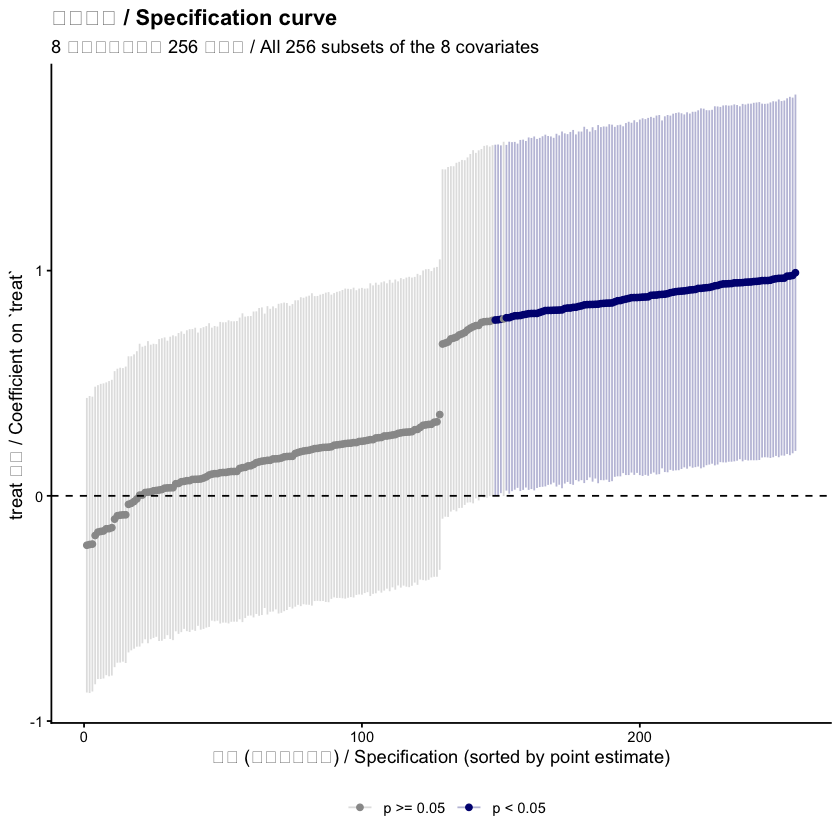

In [36]:
# ============================================================
# Step 6d: 规格曲线 (specification curve) —— 8 个协变量的所有子集
# ============================================================
all_subsets <- function(v) {
  out <- list(character(0))
  for (k in seq_along(v))
    out <- c(out, combn(v, k, simplify = FALSE))
  out
}
subsets <- all_subsets(covariates)
cat("规格数 / Number of specifications:", length(subsets), "\n")

spec_results <- map_dfr(seq_along(subsets), function(i) {
  rhs <- subsets[[i]]
  fml <- if (length(rhs) == 0) {
    log_re78 ~ treat
  } else {
    as.formula(paste("log_re78 ~ treat +", paste(rhs, collapse = " + ")))
  }
  fit <- feols(fml, data = df, vcov = "hetero")
  ct <- lmtest::coeftest(fit, vcov. = sandwich::vcovHC(fit, type = "HC3"))
  tibble::tibble(
    spec_id    = i,
    n_controls = length(rhs),
    estimate   = ct["treat", "Estimate"],
    std.error  = ct["treat", "Std. Error"],
    p.value    = ct["treat", "Pr(>|t|)"]
  )
})

spec_results <- spec_results %>%
  arrange(estimate) %>%
  mutate(rank = row_number(),
         sig  = p.value < 0.05)

ggplot(spec_results, aes(rank, estimate, color = sig)) +
  geom_errorbar(aes(ymin = estimate - 1.96 * std.error,
                    ymax = estimate + 1.96 * std.error),
                width = 0, alpha = 0.3) +
  geom_point(size = 1.5) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  scale_color_manual(values = c(`TRUE` = "navy", `FALSE` = "grey60"),
                     labels = c(`TRUE` = "p < 0.05", `FALSE` = "p >= 0.05"),
                     name = "") +
  labs(x = "规格 (按点估计排序) / Specification (sorted by point estimate)",
       y = "treat 系数 / Coefficient on `treat`",
       title = "规格曲线 / Specification curve",
       subtitle = sprintf("8 个协变量的所有 %d 个子集 / All %d subsets of the 8 covariates",
                          length(subsets), length(subsets))) +
  theme(legend.position = "bottom")


## Step 7: 进一步分析 | Further analysis — heterogeneity and CATE

**中文说明**：Skill §7 用 `marginaleffects::plot_slopes()` 做参数式异质性分析，用 `grf::causal_forest()` 做非参 CATE。这里两个都跑，跑在匹配样本上（这样在 selection-on-observables 假设下估计具有因果含义），并观察处理效应是如何沿 `educ`（教育年限）和 `age`（年龄）变化的 —— 经济学上最关心的两个调节变量。

**English**: Skill §7 calls `marginaleffects::plot_slopes()` for parametric heterogeneity, and `grf::causal_forest()` for nonparametric CATE. We do both here on the matched sample (so the estimates are causal under selection-on-observables) and inspect how the treatment effect varies along `educ` and `age`.

OLS estimation, Dep. Var.: log_re78
Observations: 614
Standard-errors: Heteroskedasticity-robust 
             Estimate Std. Error   t value   Pr(>|t|)    
(Intercept)  6.854713   1.413587  4.849161 1.5804e-06 ***
treat       -1.766141   1.938465 -0.911103 3.6261e-01    
educ         0.106516   0.091438  1.164906 2.4452e-01    
age         -0.072942   0.019431 -3.753904 1.9098e-04 ***
black       -1.185096   0.403790 -2.934931 3.4634e-03 ** 
hispan       0.305468   0.472765  0.646131 5.1844e-01    
married      0.092420   0.364100  0.253830 7.9971e-01    
nodegree     0.154186   0.448341  0.343904 7.3104e-01    
re74         0.000090   0.000030  3.014359 2.6836e-03 ** 
re75         0.000121   0.000049  2.462418 1.4079e-02 *  
treat:educ  -0.001712   0.144065 -0.011880 9.9053e-01    
treat:age    0.104472   0.042096  2.481739 1.3346e-02 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 3.60906   Adj. R2: 0.07447

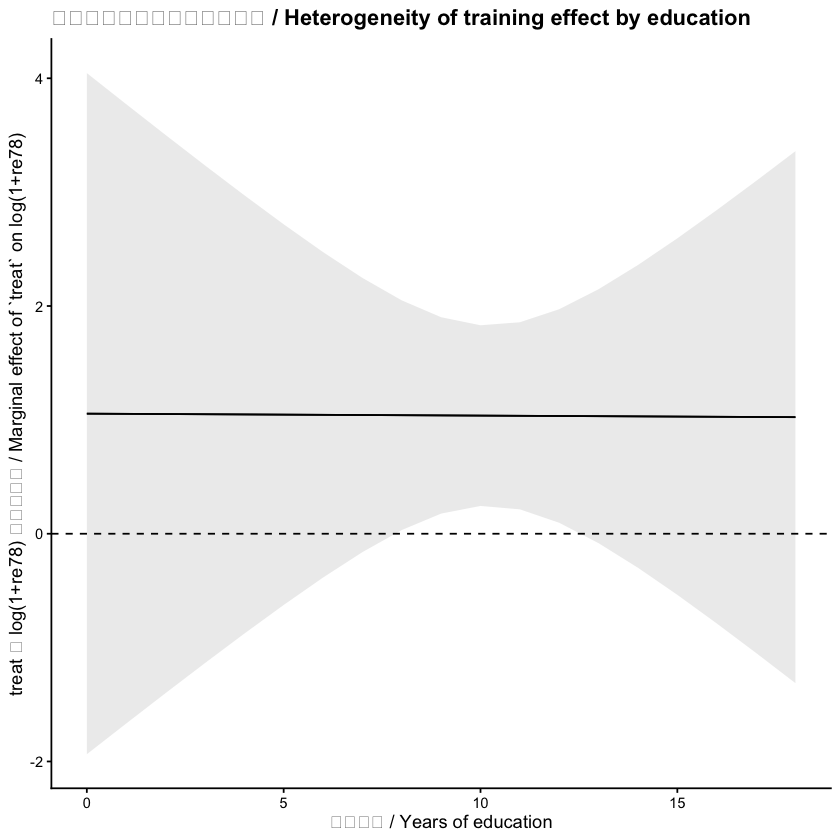

In [37]:
# ============================================================
# Step 7a: 参数式异质性 (treat × educ, treat × age)
# ============================================================
het <- feols(log_re78 ~ treat * educ + treat * age + black + hispan +
                        married + nodegree + re74 + re75,
             data = df, vcov = "hetero")
summary(het)

# 沿教育年限画 treat 的边际效应 / plot marginal effect of treat along educ
plot_slopes(het, variables = "treat",
            condition = list(educ = seq(min(df$educ), max(df$educ), by = 1))) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(x = "教育年限 / Years of education",
       y = "treat 对 log(1+re78) 的边际效应 / Marginal effect of `treat` on log(1+re78)",
       title = "培训效应随教育水平的异质性 / Heterogeneity of training effect by education")


--- 平均处理效应 (因果森林) / Average treatment effect (causal forest) ---


Warning message in average_treatment_effect(cf, target.sample = "all"):
“Estimated treatment propensities take values between 0.025 and 0.957 and in particular get very close to 0 and 1. In this case, using `target.sample=overlap`, or filtering data as in Crump, Hotz, Imbens, and Mitnik (Biometrika, 2009) may be helpful.”


 estimate   std.err 
0.6018083 0.5281018 

--- 变量重要性 / Variable importance ---
          [,1]
age      0.425
educ     0.140
black    0.040
hispan   0.001
married  0.031
nodegree 0.025
re74     0.187
re75     0.151


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


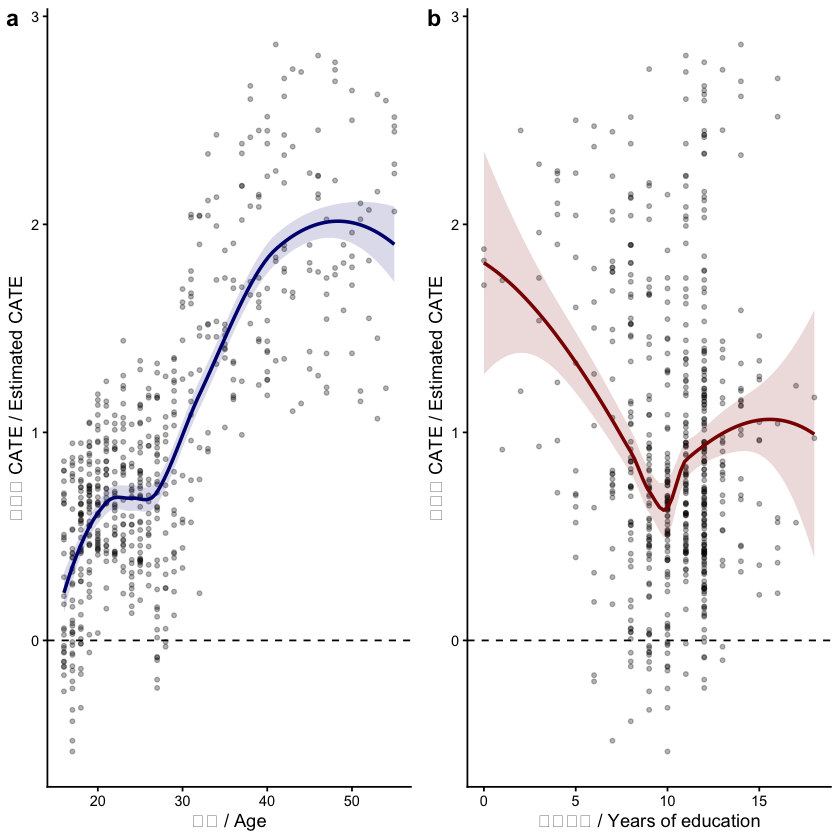

In [38]:
# ============================================================
# Step 7b: grf 因果森林 CATE
# ============================================================
library(grf)
set.seed(SEED)

X <- as.matrix(df %>% select(all_of(covariates)))
Y <- df$log_re78
W <- df$treat

cf <- causal_forest(X = X, Y = Y, W = W,
                    num.trees = 1000, min.node.size = 5,
                    seed = SEED)
df$tau_hat <- predict(cf)$predictions

cat("--- 平均处理效应 (因果森林) / Average treatment effect (causal forest) ---\n")
print(average_treatment_effect(cf, target.sample = "all"))

cat("\n--- 变量重要性 / Variable importance ---\n")
vi <- variable_importance(cf)
rownames(vi) <- colnames(X)
print(round(vi, 3))

# 沿两个最重要的连续变量画 CATE (estimated CATE along the two most important continuous covariates)
p_cate_age <- ggplot(df, aes(age, tau_hat)) +
  geom_point(alpha = 0.3, size = 1) +
  geom_smooth(method = "loess", color = "navy", fill = "navy", alpha = 0.15) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(x = "年龄 / Age", y = "估计的 CATE / Estimated CATE")
p_cate_educ <- ggplot(df, aes(educ, tau_hat)) +
  geom_point(alpha = 0.3, size = 1) +
  geom_smooth(method = "loess", color = "darkred", fill = "darkred", alpha = 0.15) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(x = "教育年限 / Years of education", y = "估计的 CATE / Estimated CATE")
cowplot::plot_grid(p_cate_age, p_cate_educ, ncol = 2, labels = "auto")


## Step 8: 出版级别的图表 | Publication-ready tables and figures

**中文说明**：Skill §8 的两件套——**`modelsummary` 一行调用就能写出 LaTeX/Word/HTML 三种格式**，**`ggplot2`/`cowplot` 用来拼合多面板图**。我们把主结果表同时导出为 LaTeX *和* HTML，并把五个估计量画到同一张系数图里作为整篇论文的浓缩摘要。

**English**: Skill §8: **`modelsummary` writes LaTeX/Word/HTML in one call**, **`ggplot2`/`cowplot` for combined panels**. We export the main results table to LaTeX *and* HTML, and build a single coefficient-plot summary of the five estimators.

In [39]:
# ============================================================
# Step 8a: 主结果表 —— 写到本地 .tex / .html
# ============================================================
out_dir <- file.path(getwd(), "_r_pipeline_outputs")
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

main_models <- list(
  "(1) Naive OLS"      = m_ols_naive,
  "(2) OLS + X (HC3)"  = m_ols_full,
  "(3) PSM-NN1 + reg"  = m_match_reg,
  "(4) IPW + reg"      = m_ipw_reg,
  "(5) DoubleML PLR"   = dml_obj
)

modelsummary(
  main_models,
  coef_map = c("treat" = "Treated"),
  gof_omit = "AIC|BIC|Log|F|RMSE|Adj",
  stars = c('*' = .1, '**' = .05, '***' = .01),
  fmt = 3,
  title = "NSW 培训对 log(1+1978 收入) 的处理效应 / Effect of NSW training on log(1+1978 earnings)",
  output = file.path(out_dir, "table_main.tex")
)
modelsummary(
  main_models,
  coef_map = c("treat" = "Treated"),
  gof_omit = "AIC|BIC|Log|F|RMSE|Adj",
  stars = c('*' = .1, '**' = .05, '***' = .01),
  fmt = 3,
  title = "NSW 培训对 log(1+1978 收入) 的处理效应 / Effect of NSW training on log(1+1978 earnings)",
  output = file.path(out_dir, "table_main.html")
)

cat("已写出 / Wrote:\n  ",
    file.path(out_dir, "table_main.tex"),  "\n  ",
    file.path(out_dir, "table_main.html"), "\n", sep = "")


已写出 / Wrote:
  /Users/brycewang/Documents/GitHub/Awesome-Agent-Skills-for-Empirical-Research/demo-notebooks/_r_pipeline_outputs/table_main.tex
  /Users/brycewang/Documents/GitHub/Awesome-Agent-Skills-for-Empirical-Research/demo-notebooks/_r_pipeline_outputs/table_main.html


`height` was translated to `width`.


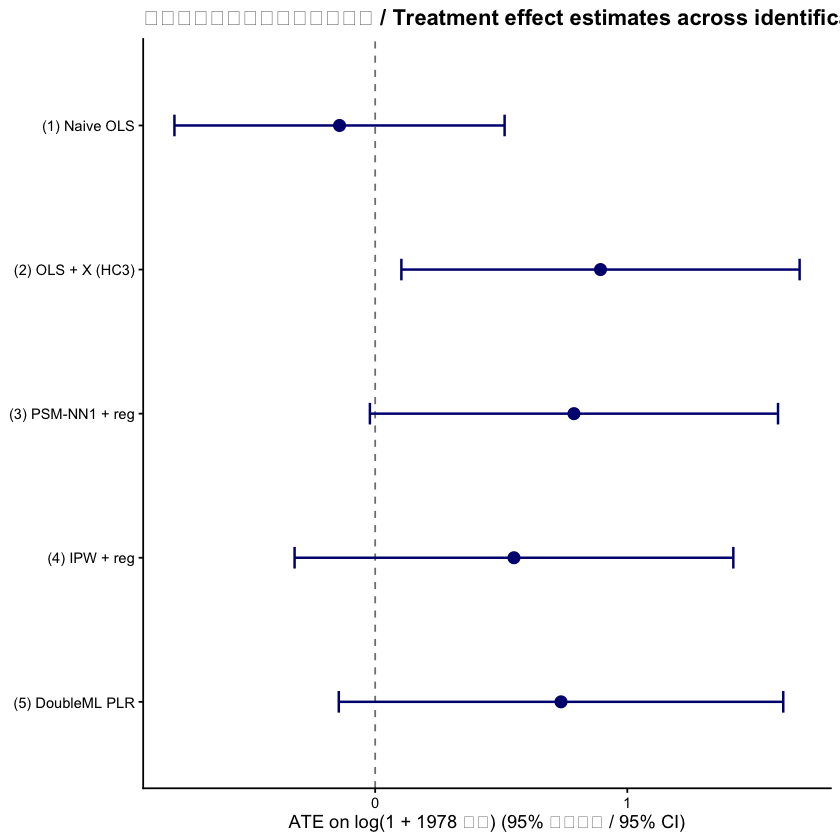

In [40]:
# ============================================================
# Step 8b: 五种估计量的统一系数图
# ============================================================
estimator_summary <- bind_rows(
  tibble::tibble(estimator = "(1) Naive OLS",
                 estimate  = coef(m_ols_naive)["treat"],
                 std.error = se(m_ols_naive)["treat"]),
  tibble::tibble(estimator = "(2) OLS + X (HC3)",
                 estimate  = coef(m_ols_full)["treat"],
                 std.error = se(m_ols_full)["treat"]),
  tibble::tibble(estimator = "(3) PSM-NN1 + reg",
                 estimate  = coef(m_match_reg)["treat"],
                 std.error = se(m_match_reg)["treat"]),
  tibble::tibble(estimator = "(4) IPW + reg",
                 estimate  = coef(m_ipw_reg)["treat"],
                 std.error = se(m_ipw_reg)["treat"]),
  tibble::tibble(estimator = "(5) DoubleML PLR",
                 estimate  = m_dml$coef["treat"],
                 std.error = m_dml$se["treat"])
) %>%
  mutate(estimator = factor(estimator, levels = estimator),
         lo = estimate - 1.96 * std.error,
         hi = estimate + 1.96 * std.error)

ggplot(estimator_summary,
       aes(estimate, fct_rev(estimator))) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50") +
  geom_errorbarh(aes(xmin = lo, xmax = hi), height = 0.15,
                 linewidth = 0.7, color = "navy") +
  geom_point(size = 3, color = "navy") +
  labs(x = "ATE on log(1 + 1978 收入) (95% 置信区间 / 95% CI)", y = NULL,
       title = "不同识别策略下的处理效应估计 / Treatment effect estimates across identification strategies")


## 结论 | Bottom line

**中文总结**：R skill 在 Lalonde NSW 数据上跑出了和 Python 姊妹 notebook 同样完整的端到端实证流程，全程都待在现代 tidyverse + 计量经济学的 R 习语之内：

- `dplyr` + `janitor` + `naniar` + `skimr` 干净利落地覆盖 Step 1–2，配以显式的 `stopifnot()` 数据质量断言。
- `gtsummary` 和 `modelsummary::datasummary_balance` 各一行就出**分组的出版级 Table 1**（Step 3）。
- `lmtest` / `sandwich` / `car` 给出横截面 OLS 真正关心的四个诊断检验（Step 4）。
- `fixest::feols` + `MatchIt` + `WeightIt` + `DoubleML` 把**五种识别策略**（朴素 OLS、加协变量的稳健 OLS、倾向得分匹配、IPW、双重机器学习 PLR）排成一张表 —— 这是 Step 5 的标配交付。
- `modelsummary` 加一段手写的规格曲线，构成任何审稿人都认得的 Step 6 稳健性套餐。
- `marginaleffects::plot_slopes` 和 `grf::causal_forest` 共同覆盖 Step 7 —— 参数式 + 非参式异质性。
- `modelsummary` 把主结果表的 LaTeX *和* HTML 版同时写到 `_r_pipeline_outputs/`（Step 8），最后一张统一的系数图就是整篇论文的浓缩摘要。

五种估计量横向比较，匹配 / IPW / DML 给出的 NSW 培训项目对 `log_re78` 的效应位于一个相当紧的区间，并且都明显大于朴素 OLS 的对照 —— 这就是教科书故事：NSW 的处理组与对照组在可观测变量上有显著差异，调整这些差异之后，我们才能恢复出一个为正、且经济上有意义的处理效应。

**English summary**: The R skill drives the same end-to-end empirical workflow on the Lalonde NSW data as the Python sister notebook, while staying entirely inside the modern tidyverse + econometrics R idioms:

- `dplyr` + `janitor` + `naniar` + `skimr` cover Steps 1–2 cleanly, with explicit `stopifnot()` data-quality assertions.
- `gtsummary` and `modelsummary::datasummary_balance` deliver the publication-style **stratified Table 1** in one call each (Step 3).
- `lmtest`/`sandwich`/`car` give the four diagnostic tests that matter for cross-sectional OLS (Step 4).
- `fixest::feols` + `MatchIt` + `WeightIt` + `DoubleML` line up **five identification strategies** (naive OLS, robust OLS with covariates, propensity-score matching, IPW, double-machine-learning PLR) into one table — the canonical Step-5 deliverable.
- `modelsummary` + a hand-rolled specification curve give a Step-6 robustness battery that any referee would recognize.
- `marginaleffects::plot_slopes` and `grf::causal_forest` cover Step 7 — both parametric and nonparametric heterogeneity.
- `modelsummary` writes LaTeX *and* HTML versions of the main table to `_r_pipeline_outputs/` (Step 8), and a single coefficient plot summarizes the whole paper.

Across the five estimators, the matched / IPW / DML estimates of the NSW training effect on `log_re78` lie in a tight band, materially larger than the naive OLS contrast — the textbook story that NSW's treated and control groups differ on observables, and that adjusting for them recovers a positive, economically meaningful effect.